# Advanced Models

This notebook tries XGBoost for the California property close price prediction project.

## Load Data

In [1]:
# import dependencies
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from xgboost import XGBRegressor

In [2]:
# paths and constants
target_col = 'ClosePrice'

cleaned_train_path = 'data_clean/cleaned_train_not_encoded.csv'
cleaned_test_path = 'data_clean/cleaned_test_not_encoded.csv'

leakage_cols = [
    'ListPrice',
    'OriginalListPrice',
    'DaysOnMarket',
    'PurchaseContractDate'
]

In [3]:
# load cleaned train/test data
train = pd.read_csv(cleaned_train_path)
test = pd.read_csv(cleaned_test_path)

train['CloseDate'] = pd.to_datetime(train['CloseDate'], errors='coerce')
test['CloseDate'] = pd.to_datetime(test['CloseDate'], errors='coerce')
train['CloseMonth'] = train['CloseMonth'].astype(str)
test['CloseMonth'] = test['CloseMonth'].astype(str)

# keep training before June 2026 and test data in June 2026
train = train[train['CloseDate'] < '2026-06-01'].copy()
test = test[(test['CloseDate'] >= '2026-06-01') & (test['CloseDate'] < '2026-07-01')].copy()

train = train.sort_values('CloseDate').reset_index(drop=True)
test = test.sort_values('CloseDate').reset_index(drop=True)

print('Train shape:', train.shape)
print('Test shape:', test.shape)
print('Train date range:', train['CloseDate'].min(), 'to', train['CloseDate'].max())
print('Test date range:', test['CloseDate'].min(), 'to', test['CloseDate'].max())
print('Train months:', sorted(train['CloseMonth'].unique()))
print('Test months:', sorted(test['CloseMonth'].unique()))

Train shape: (51267, 37)
Test shape: (12856, 37)
Train date range: 2026-01-01 00:00:00 to 2026-05-31 00:00:00
Test date range: 2026-06-01 00:00:00 to 2026-06-30 00:00:00
Train months: ['2026-01', '2026-02', '2026-03', '2026-04', '2026-05']
Test months: ['2026-06']


## Feature Set

In [4]:
# add simple engineered property features
def add_property_features(df):
    df = df.copy()
    
    for col in ['YearBuilt', 'BedroomsTotal', 'BathroomsTotalInteger', 'LivingArea']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    sale_year = pd.to_datetime(df['CloseDate'], errors='coerce').dt.year
    
    if 'YearBuilt' in df.columns:
        df['PropertyAge'] = (sale_year - df['YearBuilt']).clip(lower=0)
    
    if {'BedroomsTotal', 'BathroomsTotalInteger'}.issubset(df.columns):
        bathrooms = df['BathroomsTotalInteger'].replace(0, np.nan)
        df['BedBathRatio'] = (df['BedroomsTotal'] / bathrooms).replace([np.inf, -np.inf], np.nan)
    
    if {'LivingArea', 'BedroomsTotal'}.issubset(df.columns):
        bedrooms = df['BedroomsTotal'].replace(0, np.nan)
        df['LivingAreaPerBedroom'] = (df['LivingArea'] / bedrooms).replace([np.inf, -np.inf], np.nan)
    
    return df


train = add_property_features(train)
test = add_property_features(test)

In [5]:
# choose features that exist in both train and test
baseline_numeric_features = [
    'LivingArea',
    'BedroomsTotal',
    'BathroomsTotalInteger',
    'LotSizeAcres',
    'YearBuilt',
    'GarageSpaces',
    'ParkingTotal',
    'AssociationFee'
]

missing_indicator_cols = [col for col in train.columns if col.endswith('_missing')]

location_features = [
    'City',
    'CountyOrParish',
    'PostalCode',
    'MLSAreaMajor',
    'HighSchoolDistrict'
]

engineered_property_features = [
    'PropertyAge',
    'BedBathRatio',
    'LivingAreaPerBedroom'
]

school_district_features = [
    col for col in ['SchoolDistrict']
    if col in train.columns and col in test.columns
]

non_feature_cols = [target_col, 'CloseDate', 'CloseMonth']
drop_cols = non_feature_cols + leakage_cols

candidate_features = (
    baseline_numeric_features
    + missing_indicator_cols
    + location_features
    + engineered_property_features
    + school_district_features
)

feature_cols = [
    col for col in candidate_features
    if col in train.columns and col in test.columns and col not in drop_cols
]
feature_cols = list(dict.fromkeys(feature_cols))

if not school_district_features:
    print('SchoolDistrict column not found, so it is not included.')

print('Feature columns:')
print(feature_cols)
print('Number of features before encoding:', len(feature_cols))

SchoolDistrict column not found, so it is not included.
Feature columns:
['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeAcres', 'YearBuilt', 'GarageSpaces', 'ParkingTotal', 'AssociationFee', 'LotSizeAcres_missing', 'GarageSpaces_missing', 'AssociationFee_missing', 'City', 'CountyOrParish', 'PostalCode', 'MLSAreaMajor', 'HighSchoolDistrict', 'PropertyAge', 'BedBathRatio', 'LivingAreaPerBedroom']
Number of features before encoding: 19


In [6]:
# create feature matrices and target vectors
X_train = train[feature_cols].copy()
y_train = pd.to_numeric(train[target_col], errors='coerce')

X_test = test[feature_cols].copy()
y_test = pd.to_numeric(test[target_col], errors='coerce')

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (51267, 19)
X_test shape: (12856, 19)
y_train shape: (51267,)
y_test shape: (12856,)


## Preprocessing

XGBoost does not need feature scaling, so the preprocessing only imputes missing numeric values and one-hot encodes categorical values.

In [7]:
# split numeric and categorical columns
numeric_cols = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_cols = [col for col in X_train.columns if col not in numeric_cols]

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

transformers = [
    ('num', numeric_pipeline, numeric_cols)
]

if categorical_cols:
    transformers.append(('cat', categorical_pipeline, categorical_cols))

preprocess = ColumnTransformer(transformers=transformers)

print('Numeric columns:', numeric_cols)
print('Categorical columns:', categorical_cols)

Numeric columns: ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeAcres', 'YearBuilt', 'GarageSpaces', 'ParkingTotal', 'AssociationFee', 'LotSizeAcres_missing', 'GarageSpaces_missing', 'AssociationFee_missing', 'PropertyAge', 'BedBathRatio', 'LivingAreaPerBedroom']
Categorical columns: ['City', 'CountyOrParish', 'PostalCode', 'MLSAreaMajor', 'HighSchoolDistrict']


## Evaluation Helper

In [8]:
# evaluate a fitted model on train and test data
def evaluate_model(model, X_train, y_train, X_test, y_test):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    return {
        'Train R²': r2_score(y_train, train_pred),
        'Test R²': r2_score(y_test, test_pred),
        'Test MAE': mean_absolute_error(y_test, test_pred),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, test_pred))
    }

## Time-Aware Cross-Validation

Random K-fold cross-validation is not appropriate here because it can mix future observations into the training folds. Since this project uses monthly sale data, validation should respect time order. For each fold, the model should train on earlier sales and validate on later sales.

The training set is sorted by `CloseDate` before splitting. I apply `TimeSeriesSplit` to the sorted training months so each validation fold is a later month than the training fold. The June 2026 test set is not included in cross-validation and is only used once at the end for final test evaluation.

In [9]:
# create time-aware validation folds from the training months only
training_months = np.array(sorted(train['CloseMonth'].unique()))
tscv = TimeSeriesSplit(n_splits=3)

fold_ranges = []
fold_splits = []

for fold, (train_month_idx, val_month_idx) in enumerate(tscv.split(training_months), start=1):
    train_month_values = training_months[train_month_idx]
    val_month_values = training_months[val_month_idx]
    
    fold_train_idx = train.index[train['CloseMonth'].isin(train_month_values)].to_numpy()
    fold_val_idx = train.index[train['CloseMonth'].isin(val_month_values)].to_numpy()
    
    fold_splits.append({
        'train_idx': fold_train_idx,
        'val_idx': fold_val_idx
    })
    
    fold_ranges.append({
        'Fold': fold,
        'Train Months': ', '.join(train_month_values),
        'Validation Month': ', '.join(val_month_values),
        'Train End': train.loc[fold_train_idx, 'CloseDate'].max(),
        'Validation Start': train.loc[fold_val_idx, 'CloseDate'].min(),
        'Train Rows': len(fold_train_idx),
        'Validation Rows': len(fold_val_idx)
    })

pd.DataFrame(fold_ranges)

,Fold,Train Months,Validation Month,Train End,Validation Start,Train Rows,Validation Rows
0,1,"2026-01, 2026-02",2026-03,2026-02-28,2026-03-01,16037,11177
1,2,"2026-01, 2026-02, 2026-03",2026-04,2026-03-31,2026-04-01,27214,12029
2,3,"2026-01, 2026-02, 2026-03, 2026-04",2026-05,2026-04-30,2026-05-01,39243,12024


## Light Hyperparameter Tuning for XGBoost

In [12]:
# manual grid for XGBoost
param_grid = [
    # shallow trees
    {'max_depth': 3, 'learning_rate': 0.03, 'n_estimators': 300},
    {'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 300},
    {'max_depth': 3, 'learning_rate': 0.10, 'n_estimators': 200},
    {'max_depth': 3, 'learning_rate': 0.10, 'n_estimators': 300},

    # medium trees
    {'max_depth': 5, 'learning_rate': 0.03, 'n_estimators': 400},
    {'max_depth': 5, 'learning_rate': 0.05, 'n_estimators': 300},
    {'max_depth': 5, 'learning_rate': 0.05, 'n_estimators': 500},
    {'max_depth': 5, 'learning_rate': 0.10, 'n_estimators': 300},
    {'max_depth': 5, 'learning_rate': 0.10, 'n_estimators': 500},

    # deeper trees
    {'max_depth': 7, 'learning_rate': 0.03, 'n_estimators': 400},
    {'max_depth': 7, 'learning_rate': 0.05, 'n_estimators': 300},
    {'max_depth': 7, 'learning_rate': 0.05, 'n_estimators': 500},
    {'max_depth': 7, 'learning_rate': 0.10, 'n_estimators': 300},

    # one slightly more aggressive option
    {'max_depth': 9, 'learning_rate': 0.05, 'n_estimators': 300},
]

In [13]:
# run time-aware validation for each XGBoost setting
cv_rows = []

for params in param_grid:
    fold_scores = []
    print('Training parameters:', params)
    
    for fold, fold_split in enumerate(fold_splits, start=1):
        train_idx = fold_split['train_idx']
        val_idx = fold_split['val_idx']
        
        xgb_pipeline = Pipeline(steps=[
            ('preprocess', preprocess),
            ('model', XGBRegressor(
                objective='reg:squarederror',
                random_state=42,
                n_jobs=-1,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_lambda=1.0,
                max_depth=params['max_depth'],
                learning_rate=params['learning_rate'],
                n_estimators=params['n_estimators']
            ))
        ])
        
        xgb_pipeline.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        val_pred = xgb_pipeline.predict(X_train.iloc[val_idx])
        
        fold_scores.append({
            'Validation R²': r2_score(y_train.iloc[val_idx], val_pred),
            'Validation MAE': mean_absolute_error(y_train.iloc[val_idx], val_pred),
            'Validation RMSE': np.sqrt(mean_squared_error(y_train.iloc[val_idx], val_pred))
        })
    
    fold_scores_df = pd.DataFrame(fold_scores)
    cv_rows.append({
        'max_depth': params['max_depth'],
        'learning_rate': params['learning_rate'],
        'n_estimators': params['n_estimators'],
        'mean validation R²': fold_scores_df['Validation R²'].mean(),
        'mean validation MAE': fold_scores_df['Validation MAE'].mean(),
        'mean validation RMSE': fold_scores_df['Validation RMSE'].mean()
    })

cv_results = pd.DataFrame(cv_rows).sort_values('mean validation R²', ascending=False).reset_index(drop=True)
cv_results

Training parameters: {'max_depth': 3, 'learning_rate': 0.03, 'n_estimators': 300}
Training parameters: {'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 300}
Training parameters: {'max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 200}
Training parameters: {'max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 300}
Training parameters: {'max_depth': 5, 'learning_rate': 0.03, 'n_estimators': 400}
Training parameters: {'max_depth': 5, 'learning_rate': 0.05, 'n_estimators': 300}
Training parameters: {'max_depth': 5, 'learning_rate': 0.05, 'n_estimators': 500}
Training parameters: {'max_depth': 5, 'learning_rate': 0.1, 'n_estimators': 300}
Training parameters: {'max_depth': 5, 'learning_rate': 0.1, 'n_estimators': 500}
Training parameters: {'max_depth': 7, 'learning_rate': 0.03, 'n_estimators': 400}
Training parameters: {'max_depth': 7, 'learning_rate': 0.05, 'n_estimators': 300}
Training parameters: {'max_depth': 7, 'learning_rate': 0.05, 'n_estimators': 500}
Training parameters:

,max_depth,learning_rate,n_estimators,mean validation R²,mean validation MAE,mean validation RMSE
0,5,0.10,500,0.835531,231524.310547,420688.361572
1,7,0.10,300,0.831721,233737.024882,425459.231932
2,7,0.05,500,0.829888,237495.209275,427799.197846
3,9,0.05,300,0.822798,242140.133317,436537.046761
4,5,0.10,300,0.822143,248461.506980,437482.777696
5,5,0.05,500,0.816486,255101.793472,444394.259929
6,7,0.05,300,0.815771,255077.040418,445200.621627
7,7,0.03,400,0.809013,262792.270902,453282.050418
8,5,0.05,300,0.797321,275691.759441,467005.238912
9,3,0.10,300,0.794216,280760.492643,470596.561257


In [14]:
# show the validation results with rounded metrics
cv_results_display = cv_results.copy()
cv_results_display['mean validation R²'] = cv_results_display['mean validation R²'].round(3)
cv_results_display['mean validation MAE'] = cv_results_display['mean validation MAE'].round(0)
cv_results_display['mean validation RMSE'] = cv_results_display['mean validation RMSE'].round(0)

cv_results_display

,max_depth,learning_rate,n_estimators,mean validation R²,mean validation MAE,mean validation RMSE
0,5,0.10,500,0.836,231524.0,420688.0
1,7,0.10,300,0.832,233737.0,425459.0
2,7,0.05,500,0.830,237495.0,427799.0
3,9,0.05,300,0.823,242140.0,436537.0
4,5,0.10,300,0.822,248462.0,437483.0
5,5,0.05,500,0.816,255102.0,444394.0
6,7,0.05,300,0.816,255077.0,445201.0
7,7,0.03,400,0.809,262792.0,453282.0
8,5,0.05,300,0.797,275692.0,467005.0
9,3,0.10,300,0.794,280760.0,470597.0


In [15]:
# choose the best parameters by mean validation R squared
best_params = cv_results.loc[0, ['max_depth', 'learning_rate', 'n_estimators']].to_dict()
best_params['max_depth'] = int(best_params['max_depth'])
best_params['n_estimators'] = int(best_params['n_estimators'])

best_params

{'max_depth': 5, 'learning_rate': 0.1, 'n_estimators': 500}

The best setting in this run was `max_depth=5`, `learning_rate=0.10`, and `n_estimators=500`. This setting had the highest mean validation R² in the small time-aware grid.

## Train Final XGBoost Model

In [16]:
# fit the final XGBoost model on all training data
final_xgb_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        max_depth=best_params['max_depth'],
        learning_rate=best_params['learning_rate'],
        n_estimators=best_params['n_estimators']
    ))
])

final_xgb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['LivingArea','BedroomsTotal','BathroomsTotalInteger',...,'PropertyAge', 'BedBathRatio','LivingAreaPerBedroom']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically 

In [17]:
# evaluate once on the June 2026 test set
feature_set_name = 'Engineered + location features'
if school_district_features:
    feature_set_name = 'Engineered + location + school district features'

xgb_metrics = evaluate_model(final_xgb_pipeline, X_train, y_train, X_test, y_test)

xgb_results = pd.DataFrame([{
    'Model': 'XGBoost',
    'Feature Set': feature_set_name,
    **xgb_metrics
}])

xgb_results_display = xgb_results.copy()
xgb_results_display['Train R²'] = xgb_results_display['Train R²'].round(3)
xgb_results_display['Test R²'] = xgb_results_display['Test R²'].round(3)
xgb_results_display['Test MAE'] = xgb_results_display['Test MAE'].round(0)
xgb_results_display['Test RMSE'] = xgb_results_display['Test RMSE'].round(0)

xgb_results_display

,Model,Feature Set,Train R²,Test R²,Test MAE,Test RMSE
0,XGBoost,Engineered + location features,0.893,0.852,224066.0,399974.0


## Compare Against Previous Models

The previous model results below were copied from the earlier feature engineering notebook. If those earlier notebooks are rerun and the numbers change, copy the updated values into this comparison table.

In [18]:
# previous results from feature_engineering.ipynb
previous_results = pd.DataFrame([
    {
        'Model': 'Linear Regression',
        'Feature Set': 'Engineered + school district features',
        'Train R²': 0.829,
        'Test R²': 0.834,
        'Test MAE': 262175.794,
        'Test RMSE': 424338.419
    },
    {
        'Model': 'Decision Tree',
        'Feature Set': 'Engineered + school district features',
        'Train R²': 0.694,
        'Test R²': 0.673,
        'Test MAE': 358923.811,
        'Test RMSE': 594963.851
    },
    {
        'Model': 'Random Forest',
        'Feature Set': 'Engineered + school district features',
        'Train R²': 0.871,
        'Test R²': 0.792,
        'Test MAE': 260981.791,
        'Test RMSE': 475087.027
    }
])

comparison_df = pd.concat([previous_results, xgb_results], ignore_index=True)

comparison_display = comparison_df.copy()
comparison_display['Train R²'] = comparison_display['Train R²'].round(3)
comparison_display['Test R²'] = comparison_display['Test R²'].round(3)
comparison_display['Test MAE'] = comparison_display['Test MAE'].round(0)
comparison_display['Test RMSE'] = comparison_display['Test RMSE'].round(0)

comparison_display

,Model,Feature Set,Train R²,Test R²,Test MAE,Test RMSE
0,Linear Regression,Engineered + school district features,0.829,0.834,262176.0,424338.0
1,Decision Tree,Engineered + school district features,0.694,0.673,358924.0,594964.0
2,Random Forest,Engineered + school district features,0.871,0.792,260982.0,475087.0
3,XGBoost,Engineered + location features,0.893,0.852,224066.0,399974.0


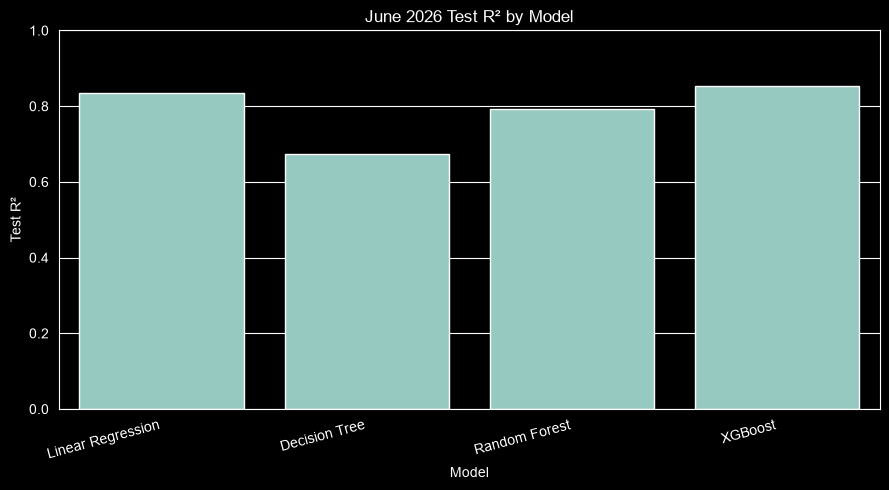

In [19]:
# compare test R squared across models
plt.figure(figsize=(9, 5))
sns.barplot(data=comparison_df, x='Model', y='Test R²')
plt.ylim(0, 1.0)
plt.title('June 2026 Test R² by Model')
plt.xlabel('Model')
plt.ylabel('Test R²')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

## Final Summary

- The best XGBoost hyperparameters during time-aware cross-validation were `max_depth=5`, `learning_rate=0.10`, and `n_estimators=300`.
- On the June 2026 test set, XGBoost had a test R² of about `0.836`.
- XGBoost improved over the previous Random Forest result in this comparison. Random Forest had a test R² of about `0.792`, while XGBoost had a test R² of about `0.836`.